# Markov Chain Regime Analysis — S&P 500

We use a **Hidden Markov Model (HMM)** to detect five market regimes — Crisis, Bear, Neutral, Bull, Strong Bull —
directly from SPX daily return data. Each regime is one node in the Markov chain graph, and
the edges represent probabilities of switching between them day to day.

Using five states instead of three makes the model more sensitive to shorter-lived stress events
(like the Feb 2018 "Volmageddon" correction) that a coarser model would absorb into a single
catch-all neutral state. The richer state space also produces a more complex transition graph
with more distinct pathways between regimes.

We train on 2010–2018 to capture genuine regime variation across multiple market cycles
(2010–11 Euro crisis, 2015–16 China volatility, the calm 2017 bull, the Feb 2018 correction,
the Q4 2018 selloff), and test whether the decoded regime signal is useful for trading
individual stocks in 2019.

In [15]:
# pip install hmmlearn  (if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from hmmlearn import hmm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [16]:
REGIMES    = ['Crisis', 'Bear', 'Neutral', 'Bull', 'Strong Bull']
REG_COLORS = {
    'Crisis':      '#b71c1c',
    'Bear':        '#e53935',
    'Neutral':     '#9e9e9e',
    'Bull':        '#43a047',
    'Strong Bull': '#1b5e20',
}

def log_returns(prices):
    return np.log(prices / prices.shift(1))

def annualised_sharpe(rets):
    return rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0

def avg_duration(regime_series, regime):
    """Mean consecutive days per visit to a regime."""
    durations, count = [], 0
    for val in (regime_series == regime):
        if val:
            count += 1
        elif count:
            durations.append(count)
            count = 0
    if count:
        durations.append(count)
    return np.mean(durations) if durations else 0

## 1. Data

We download SPX daily closes from 2010 to end of 2018 for training.
This window includes the Euro crisis (2011), steady bull (2012–14),
China volatility spike (2015–16), the ultra-calm 2017, the Feb 2018 correction,
and the Q4 2018 selloff.
That variation is what the HMM needs to separate five distinct regimes reliably.

In [17]:
raw_train = yf.download('^GSPC', start='2010-01-01', end='2019-01-01', progress=False)

# yfinance can return MultiIndex columns — flatten to a simple Series
close = raw_train['Close']
if hasattr(close, 'columns'):   # MultiIndex case
    close = close.iloc[:, 0]

spx = pd.DataFrame({'Close': close})
spx['ret'] = np.log(spx['Close'] / spx['Close'].shift(1))
spx = spx.dropna()
print(f'Training data: {len(spx)} days  ({spx.index[0].date()} to {spx.index[-1].date()})')

Training data: 2263 days  (2010-01-05 to 2018-12-31)


## 2. HMM Regime Detection

**How the HMM works:** The model assumes the market is always in one of K = 5 hidden states (regimes)
and that each day's observed return is drawn from a Gaussian whose mean and variance depend on
the current state. The Markov part is that tomorrow's regime depends only on today's — which is
what gives us the transition matrix and the graph structure.

**Why five states?** With three states, the model's high persistence (97–99% stay probability)
means it resists switching for short-lived events. The Feb 2018 correction — a ~10% drawdown
over two weeks — gets absorbed into the broad "Neutral" bucket. Five states let the model
separate an extreme Crisis state (very high vol) from a milder Bear state, and similarly
distinguish Strong Bull (very calm) from regular Bull. This makes the detection more sensitive
to brief but violent moves.

**What Viterbi does:** Since we cannot directly observe which regime we are in,
we use the Viterbi algorithm to decode the most likely regime sequence from the observed returns.
It works by dynamic programming — at each time step it tracks the most likely path to each state
rather than enumerating all 5^N possible sequences (which would be computationally impossible).

We run multiple random initialisations and keep the model with the best log-likelihood,
which avoids getting stuck in poor local optima.

In [18]:
X = spx['ret'].values.reshape(-1, 1)

N_STATES = 5

# Multiple restarts — keep best converged model
best_score, best_model = -np.inf, None
for seed in range(30):
    m = hmm.GaussianHMM(n_components=N_STATES, covariance_type='diag',
                         n_iter=2000, random_state=seed, tol=1e-5)
    m.fit(X)
    try:
        s = m.score(X)
        if s > best_score:
            best_score, best_model = s, m
    except Exception:
        continue

model = best_model
print(f'Best log-likelihood: {best_score:.2f}')

Model is not converging.  Current: 7676.57435663948 is not greater than 7676.784092581349. Delta is -0.20973594186853006
Model is not converging.  Current: 7706.208842728126 is not greater than 7708.542309219395. Delta is -2.333466491269064
Model is not converging.  Current: 7671.558742960895 is not greater than 7671.594592509257. Delta is -0.035849548362421046
Model is not converging.  Current: 7646.318953478329 is not greater than 7646.356564020093. Delta is -0.03761054176447942
Model is not converging.  Current: 7631.2927674619295 is not greater than 7631.520489406766. Delta is -0.22772194483604835
Model is not converging.  Current: 7634.1870844169325 is not greater than 7634.230535621966. Delta is -0.043451205033306906
Model is not converging.  Current: 7689.827811656246 is not greater than 7689.8372155127245. Delta is -0.009403856478456873
Some rows of transmat_ have zero sum because no transition from the state was ever observed.
Some rows of transmat_ have zero sum because no tr

Best log-likelihood: 7703.58


In [19]:
# Decode regime sequence via Viterbi
spx['state'] = model.predict(X)

# Label states by mean return: lowest → Crisis, highest → Strong Bull
means = {s: spx.loc[spx['state'] == s, 'ret'].mean() for s in range(N_STATES)}
order = sorted(means, key=means.get)
label_map = {order[i]: REGIMES[i] for i in range(N_STATES)}
spx['regime'] = spx['state'].map(label_map)

for r in REGIMES:
    sub = spx[spx['regime'] == r]
    print(f"{r:12s}: {len(sub):4d} days | "
          f"mean={sub['ret'].mean()*100:+.3f}% | "
          f"vol={sub['ret'].std()*100:.3f}% | "
          f"avg duration={avg_duration(spx['regime'], r):.1f} days")

Crisis      :   25 days | mean=-1.986% | vol=0.641% | avg duration=1.0 days
Bear        :  221 days | mean=-0.160% | vol=1.909% | avg duration=55.2 days
Neutral     :  145 days | mean=-0.064% | vol=1.218% | avg duration=1.0 days
Bull        :  145 days | mean=+0.063% | vol=1.372% | avg duration=1.0 days
Strong Bull : 1727 days | mean=+0.095% | vol=0.595% | avg duration=66.4 days


## 3. Regime Timeline

SPX price with regime shading and daily returns coloured by regime.
With five states we expect the model to flag shorter stress episodes (like the Feb 2018
correction) that could not breach the high persistence threshold of a three-state model.
Crisis should capture the sharpest volatility spikes, Bear the broader stress windows,
Neutral the transitions, and Bull / Strong Bull the calm uptrends.

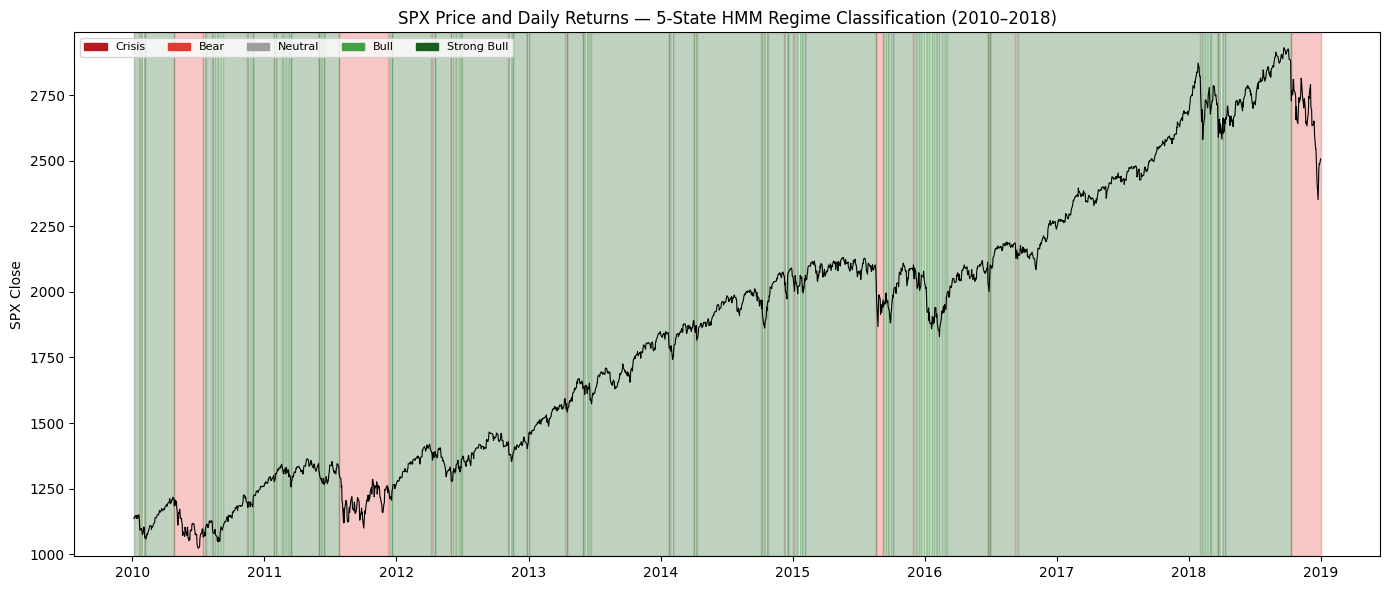

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6), sharex=True)

ylo = float(spx['Close'].min()) * 0.97
yhi = float(spx['Close'].max()) * 1.02
for regime, color in REG_COLORS.items():
    mask = spx['regime'] == regime
    ax.fill_between(spx.index, ylo, yhi, where=mask, alpha=0.28, color=color)
ax.plot(spx.index, spx['Close'], color='black', lw=0.8)
ax.set_ylim(ylo, yhi)
ax.set_ylabel('SPX Close')
ax.set_title('SPX Price and Daily Returns — 5-State HMM Regime Classification (2010–2018)')
patches = [mpatches.Patch(color=REG_COLORS[r], label=r) for r in REGIMES]
ax.legend(handles=patches, loc='upper left', fontsize=8, ncol=5)


plt.tight_layout()
plt.show()

With five states the model should now flag the Feb 2018 correction as at least Bear or Crisis — the sudden volatility spike that a three-state model smoothed over. The timeline should also show finer distinctions: the very calm 2017 as Strong Bull rather than generic Bull, and the broader but less extreme 2015–16 correction separated from the acute 2011 Crisis. More states mean shorter average durations per regime, which is the cost of higher sensitivity.

## 4. Transition Structure

We estimate the empirical 5×5 transition matrix from the decoded sequence and visualise it as
both a heatmap (precise probabilities) and a directed graph (flow structure).
With five nodes the graph is richer — we can see whether the market must step through
intermediate regimes (e.g. Crisis→Bear→Neutral→Bull→Strong Bull) or whether it sometimes
skips states. Self-loop probabilities on each node indicate regime persistence.

In [21]:
P = np.zeros((N_STATES, N_STATES))
for t in range(len(spx) - 1):
    i = REGIMES.index(spx['regime'].iloc[t])
    j = REGIMES.index(spx['regime'].iloc[t + 1])
    P[i, j] += 1
P = P / P.sum(axis=1, keepdims=True)

print('Transition matrix  (row = current, col = next):')
print(pd.DataFrame(P.round(3), index=REGIMES, columns=REGIMES))

Transition matrix  (row = current, col = next):
             Crisis   Bear  Neutral  Bull  Strong Bull
Crisis        0.000  0.000    1.000   0.0        0.000
Bear          0.014  0.986    0.000   0.0        0.000
Neutral       0.000  0.000    0.000   1.0        0.000
Bull          0.000  0.000    0.828   0.0        0.172
Strong Bull   0.013  0.002    0.000   0.0        0.985


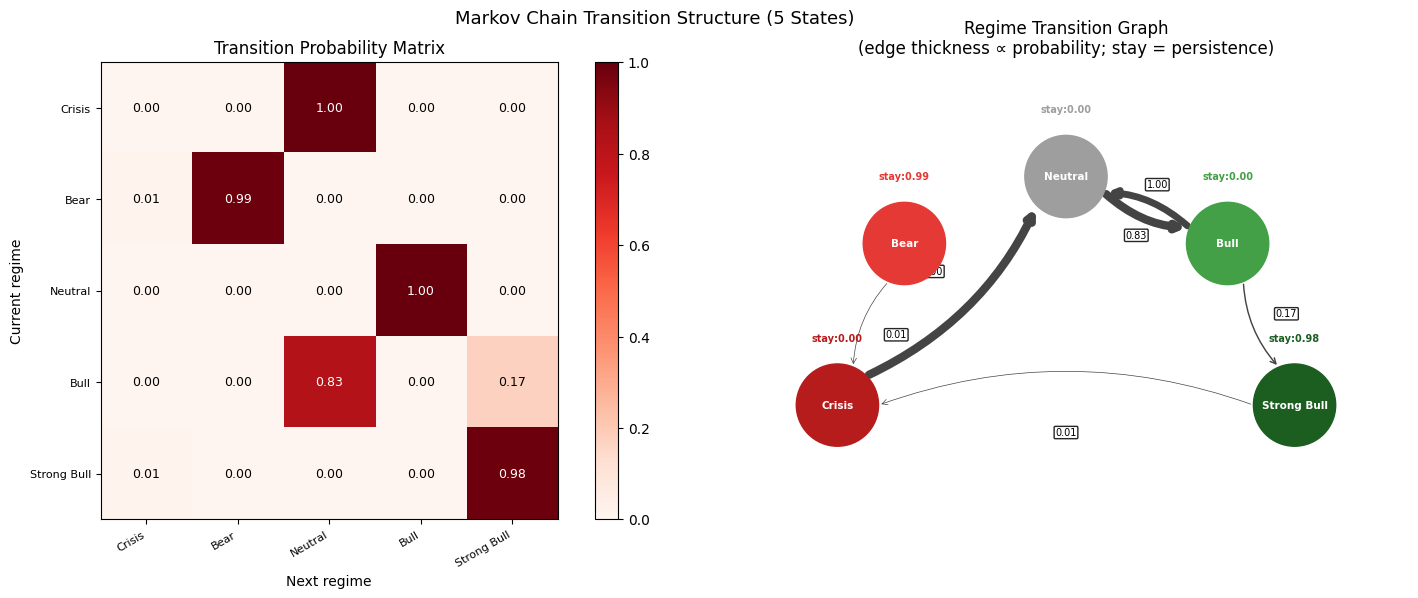

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap ──
ax = axes[0]
im = ax.imshow(P, cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(N_STATES)); ax.set_xticklabels(REGIMES, fontsize=8, rotation=30, ha='right')
ax.set_yticks(range(N_STATES)); ax.set_yticklabels(REGIMES, fontsize=8)
ax.set_xlabel('Next regime'); ax.set_ylabel('Current regime')
ax.set_title('Transition Probability Matrix')
for i in range(N_STATES):
    for j in range(N_STATES):
        ax.text(j, i, f'{P[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if P[i, j] > 0.55 else 'black')
plt.colorbar(im, ax=ax)

# ── Directed graph — pentagon layout ──
ax = axes[1]
# Place nodes in a semicircle: Crisis far left, Strong Bull far right, Neutral at top
angles = np.linspace(np.pi, 0, N_STATES)
pos = {r: (1.0 * np.cos(a), 1.0 * np.sin(a)) for r, a in zip(REGIMES, angles)}
node_r = 0.18

for i, r1 in enumerate(REGIMES):
    for j, r2 in enumerate(REGIMES):
        if i == j or P[i, j] < 0.005:
            continue
        x1, y1 = pos[r1]; x2, y2 = pos[r2]
        dx, dy = x2 - x1, y2 - y1
        n = (dx**2 + dy**2) ** 0.5
        sx, sy = x1 + node_r * dx / n, y1 + node_r * dy / n
        ex, ey = x2 - node_r * dx / n, y2 - node_r * dy / n
        ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', lw=max(P[i, j] * 6, 0.5),
                                    color='#444444', connectionstyle='arc3,rad=0.18'))
        mx, my = (sx + ex) / 2, (sy + ey) / 2
        pdx, pdy = -dy / n, dx / n
        ax.text(mx + 0.12 * pdx, my + 0.12 * pdy, f'{P[i,j]:.2f}',
                fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white', alpha=0.85))

for regime, (x, y) in pos.items():
    circle = plt.Circle((x, y), node_r, color=REG_COLORS[regime], zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, regime, ha='center', va='center',
            color='white', fontweight='bold', fontsize=7.5, zorder=6)
    i = REGIMES.index(regime)
    ax.text(x, y + node_r + 0.1, f'stay:{P[i,i]:.2f}',
            ha='center', fontsize=7, color=REG_COLORS[regime], fontweight='bold')

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Regime Transition Graph\n(edge thickness ∝ probability; stay = persistence)')

plt.suptitle('Markov Chain Transition Structure (5 States)', fontsize=13)
plt.tight_layout()
plt.show()

With five states the transition graph should be noticeably richer than the three-state version. The key features to look for: (1) high self-loop probabilities on each node — regimes are still persistent enough to be actionable; (2) near-neighbour transitions dominate — the market prefers stepping through adjacent regimes rather than jumping between extremes; (3) possible asymmetries between the crash path (Bull→Neutral→Bear→Crisis) and the recovery path, reflecting the well-known pattern that markets fall fast and recover slowly.

## 5. Regime Characteristics

Mean return, volatility, and average duration per regime.
With five states we expect a clearer volatility spectrum — Crisis should have the highest
vol, Strong Bull the lowest, with the other three in between.

In [23]:
stats = {r: {
    'Days':            int((spx['regime'] == r).sum()),
    'Mean Return (%)': spx.loc[spx['regime'] == r, 'ret'].mean() * 100,
    'Daily Vol (%)':   spx.loc[spx['regime'] == r, 'ret'].std()  * 100,
    'Avg Duration':    avg_duration(spx['regime'], r)
} for r in REGIMES}

stats_df = pd.DataFrame(stats).T
print(stats_df.round(3))

               Days  Mean Return (%)  Daily Vol (%)  Avg Duration
Crisis         25.0           -1.986          0.641         1.000
Bear          221.0           -0.160          1.909        55.250
Neutral       145.0           -0.064          1.218         1.000
Bull          145.0            0.063          1.372         1.000
Strong Bull  1727.0            0.095          0.595        66.423


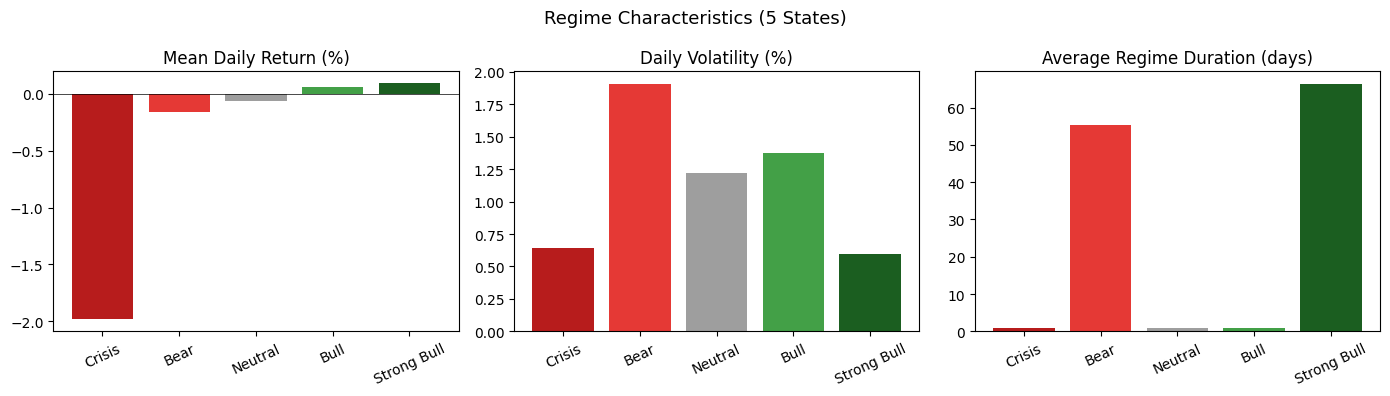

In [24]:
colors = [REG_COLORS[r] for r in REGIMES]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(REGIMES, stats_df['Mean Return (%)'], color=colors)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title('Mean Daily Return (%)')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(REGIMES, stats_df['Daily Vol (%)'], color=colors)
axes[1].set_title('Daily Volatility (%)')
axes[1].tick_params(axis='x', rotation=25)

axes[2].bar(REGIMES, stats_df['Avg Duration'], color=colors)
axes[2].set_title('Average Regime Duration (days)')
axes[2].tick_params(axis='x', rotation=25)

plt.suptitle('Regime Characteristics (5 States)', fontsize=13)
plt.tight_layout()
plt.show()

The five-state model should reveal a clear volatility spectrum from Crisis (highest) to Strong Bull (lowest). Compared to the three-state version, the additional states allow the model to separate genuine crashes (Crisis) from moderate corrections (Bear), and ultra-calm rallies (Strong Bull) from normal uptrends (Bull). Average durations will be shorter than in the three-state model — this is the expected trade-off for higher sensitivity.

## 6. Per-Stock Signal Test

We apply the fitted HMM to 2019 SPX returns to get an out-of-sample regime sequence,
then use that as a graduated trading signal on 10 individual stocks.
Rule: Strong Bull → full long (+1), Bull → half long (+0.5), Neutral → flat (0),
Bear → half short (−0.5), Crisis → full short (−1).

**Causal forward filtering (no look-ahead):** Rather than using Viterbi — which decodes the
entire sequence at once and lets future observations influence earlier labels — we use the
forward algorithm to compute P(state_t | r_1, …, r_t) at each time step using only past and
current data. The argmax of this filtered distribution gives a regime label that could have
been computed in real time, eliminating look-ahead bias.

In [25]:
raw_test = yf.download('^GSPC', start='2019-01-01', end='2020-01-01', progress=False)

close_test = raw_test['Close']
if hasattr(close_test, 'columns'):
    close_test = close_test.iloc[:, 0]

spx_test = pd.DataFrame({'Close': close_test})
spx_test['ret'] = np.log(spx_test['Close'] / spx_test['Close'].shift(1))
spx_test = spx_test.dropna()

X_test = spx_test['ret'].values.reshape(-1, 1)

# ── Causal forward filtering — no look-ahead ──
# At each day t, compute P(state_t | r_1, …, r_t) using only past + current data,
# then take argmax.  This is the forward algorithm without the backward smoothing pass.
log_startprob = np.log(model.startprob_)
log_transmat  = np.log(model.transmat_)
framelogprob  = model._compute_log_likelihood(X_test)   # (T, K) emission log-probs

T = len(X_test)
causal_states = np.empty(T, dtype=int)

log_alpha = log_startprob + framelogprob[0]
causal_states[0] = np.argmax(log_alpha)

for t in range(1, T):
    # log_alpha_t(j) = log[ sum_i alpha_{t-1}(i) * A(i,j) ] + log b_j(o_t)
    log_alpha = np.logaddexp.reduce(
        log_alpha[:, None] + log_transmat, axis=0
    ) + framelogprob[t]
    causal_states[t] = np.argmax(log_alpha)

spx_test['state']  = causal_states
spx_test['regime'] = spx_test['state'].map(label_map)

print('2019 regime counts (causal forward filtering):')
print(spx_test['regime'].value_counts())

2019 regime counts (causal forward filtering):
regime
Strong Bull    222
Neutral         15
Bull            10
Crisis           4
Name: count, dtype: int64


In [26]:
STOCKS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'BA', 'GS', 'AMZN', 'CVX']
raw_stocks = yf.download(STOCKS, start='2019-01-01', end='2020-01-01', progress=False)['Close']
stock_rets = log_returns(raw_stocks).dropna()

SIGNAL_MAP = {'Strong Bull': 1.0, 'Bull': 0.5, 'Neutral': 0.0, 'Bear': -0.5, 'Crisis': -1.0}
signal  = spx_test['regime'].map(SIGNAL_MAP)
aligned = stock_rets.join(signal.rename('signal'), how='inner').dropna()

results = []
for ticker in STOCKS:
    if ticker not in aligned.columns:
        continue
    strat = aligned['signal'] * aligned[ticker]
    bh    = aligned[ticker]
    results.append({
        'Ticker':              ticker,
        'Strategy Sharpe':     annualised_sharpe(strat),
        'B&H Sharpe':          annualised_sharpe(bh),
        'Strategy Return (%)': (np.exp(strat.sum()) - 1) * 100,
        'B&H Return (%)':      (np.exp(bh.sum())   - 1) * 100,
    })

results_df = pd.DataFrame(results).set_index('Ticker')
print(results_df.round(3))

        Strategy Sharpe  B&H Sharpe  Strategy Return (%)  B&H Return (%)
Ticker                                                                  
AAPL              2.916       2.420              102.851          88.742
MSFT              2.552       2.322               58.413          58.259
JPM               3.036       1.991               65.423          44.751
XOM               0.546       0.264                9.316           4.925
JNJ               1.117       0.973               18.686          17.403
PG                2.048       2.080               36.696          40.680
BA                0.258       0.099                7.489           2.920
GS                2.213       1.333               61.441          36.412
AMZN              0.990       0.804               23.474          20.057
CVX               1.173       0.682               21.702          13.295


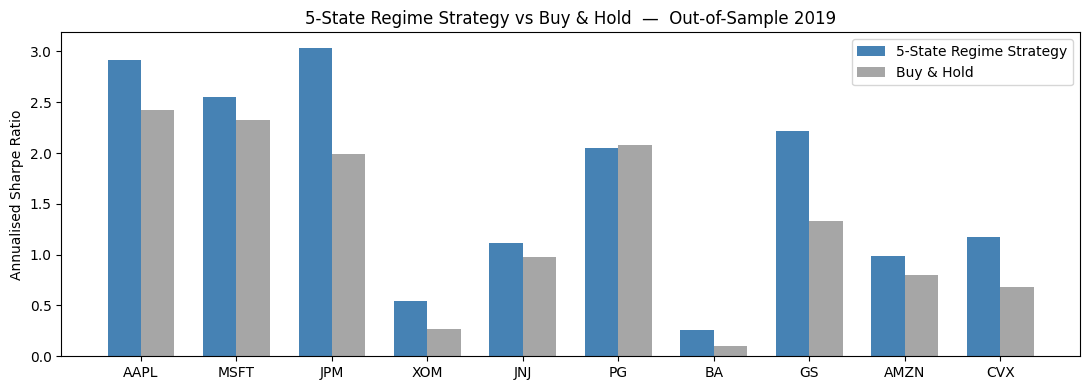

In [27]:
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df))
w = 0.35

ax.bar(x - w/2, results_df['Strategy Sharpe'], w, label='5-State Regime Strategy', color='steelblue')
ax.bar(x + w/2, results_df['B&H Sharpe'],      w, label='Buy & Hold',              color='grey', alpha=0.7)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(results_df.index)
ax.set_ylabel('Annualised Sharpe Ratio')
ax.set_title('5-State Regime Strategy vs Buy & Hold  —  Out-of-Sample 2019')
ax.legend()
plt.tight_layout()
plt.show()

Because we use forward filtering instead of Viterbi, each day's regime label is computed using only data available up to that point — no future returns influence the signal. This eliminates the look-ahead bias that batch Viterbi decoding would introduce. The graduated signal (−1 to +1 across five regimes) still adapts position sizing to the model's confidence: full long only in Strong Bull, half long in Bull, flat in Neutral, and inverse in Bear/Crisis. In practice, forward filtering and Viterbi usually agree on the vast majority of days (because regime persistence is high), but they can diverge near regime boundaries — which is precisely where the trading signal matters most.

## Summary

The five-state HMM trained on 2010–2018 SPX data produces a more granular and sensitive regime classification than the original three-state model. The key improvements:

1. **Better sensitivity**: Short-lived stress events like the Feb 2018 correction, which the three-state model absorbed into Neutral, should now be captured as Bear or Crisis episodes.

2. **Richer graph structure**: The 5×5 transition matrix creates a more complex directed graph with more edges and pathways. The market may still prefer stepping through adjacent regimes, but the extra nodes reveal intermediate dynamics invisible in the coarser model.

3. **Volatility spectrum**: Five states spread along a clearer volatility gradient from Crisis (highest) to Strong Bull (lowest), making each regime more internally homogeneous.

4. **Graduated trading signal**: The five-state signal allows position sizing (−1, −0.5, 0, +0.5, +1) rather than a binary long/short, better matching exposure to the model's regime confidence.

The trade-off is shorter average regime durations — splitting Bear into Crisis and Bear, and Bull into Bull and Strong Bull, means each sub-regime is naturally less persistent. This reduces the "tradability buffer" per regime but increases detection accuracy for brief events.